In [1]:
import pandas as pd
data=pd.read_csv('diseased.csv')
data.tail()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
1995,1,1,0,0,1,0,0,0,1,1,Alcoholic hepatitis
1996,1,0,0,0,1,1,1,0,1,1,Alcoholic hepatitis
1997,1,0,0,1,0,0,0,0,0,1,Alcoholic hepatitis
1998,0,0,0,0,1,1,0,0,0,1,Alcoholic hepatitis
1999,0,0,0,1,1,1,0,0,0,1,Alcoholic hepatitis


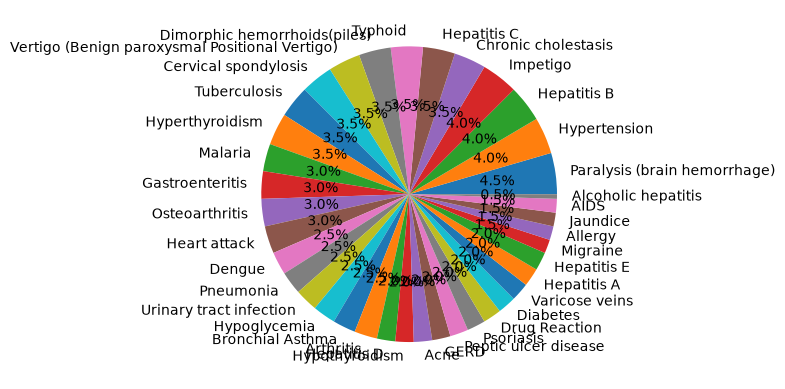

In [2]:
import matplotlib.pyplot as plt
ax=data['disease'].value_counts().plot.pie(autopct='%1.1f%%')

In [3]:
data['disease'].value_counts()

disease
Paralysis (brain hemorrhage)                      90
Hypertension                                      80
Hepatitis B                                       80
Impetigo                                          80
Chronic cholestasis                               70
Hepatitis C                                       70
Typhoid                                           70
Dimorphic hemorrhoids(piles)                      70
Vertigo (Benign paroxysmal Positional Vertigo)    70
Cervical spondylosis                              70
Tuberculosis                                      70
Hyperthyroidism                                   70
Malaria                                           60
Gastroenteritis                                   60
Osteoarthritis                                    60
Heart attack                                      60
Dengue                                            50
Pneumonia                                         50
Urinary tract infection               

In [4]:
data.isnull().sum()

fever          0
headache       0
nausea         0
vomiting       0
fatigue        0
joint_pain     0
skin_rash      0
cough          0
weight_loss    0
yellow_eyes    0
disease        0
dtype: int64

In [5]:
filtered_disease=data[data['disease']=='Diabetes']
filtered_disease.head()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
1710,1,0,1,0,0,0,0,0,0,1,Diabetes
1711,1,0,0,1,0,0,0,0,0,1,Diabetes
1712,1,0,0,1,0,0,0,0,1,1,Diabetes
1713,1,0,1,0,1,0,0,0,0,1,Diabetes
1714,1,0,0,0,0,1,1,0,0,1,Diabetes


Text(0.5, 1.0, 'Disease class distribution before resampling')

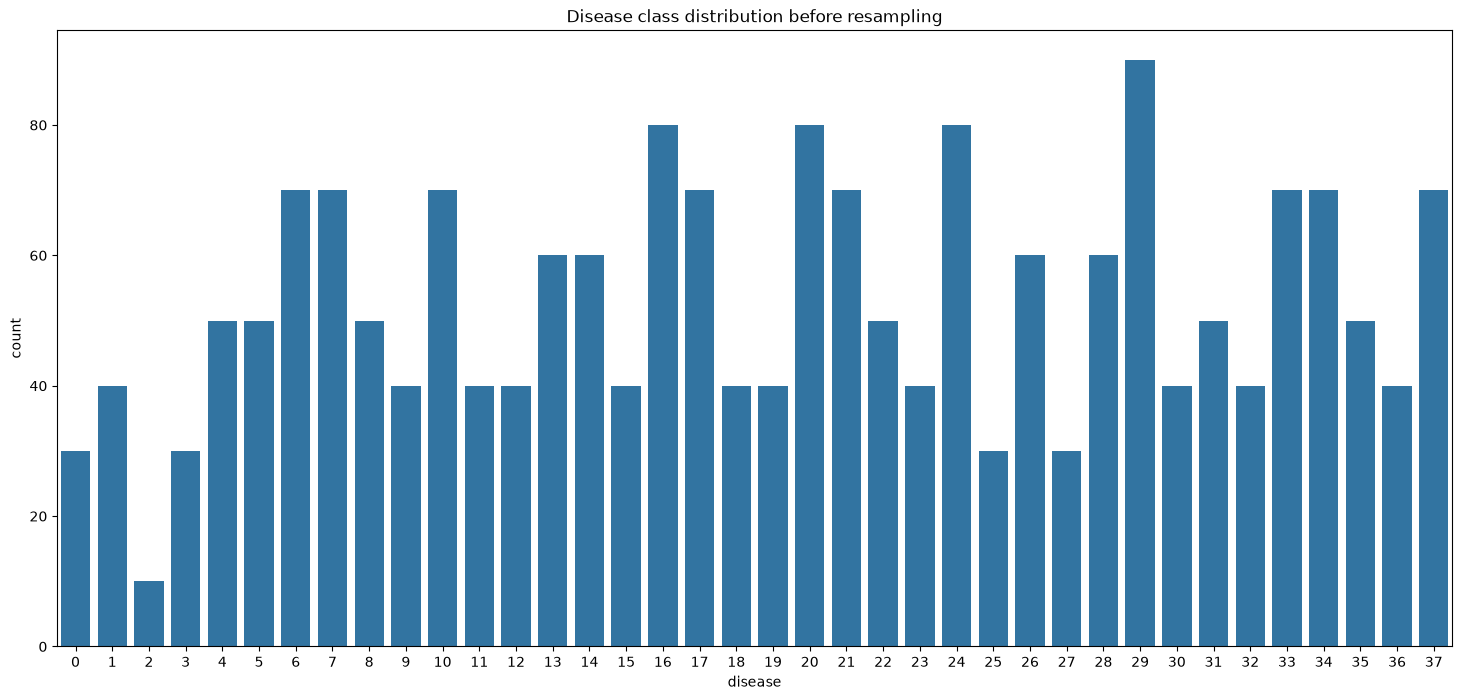

In [6]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
# convert single column/list of categories to numbers(0 to num_of_categories-1)
data['disease']=encoder.fit_transform(data['disease'])
# fit_transform cannot use in the input test set 
X=data.iloc[:,:-1]
y=data.iloc[:,-1]
plt.figure(figsize=(18,8))

import seaborn as sns
sns.countplot(x=y)
# put the coded disease number on the x axis
plt.title("Disease class distribution before resampling")


In [7]:
# import sys
# print(sys.executable)
# %pip install --force-reinstall imbalanced-learn

In [8]:
import sys
print("--- DIAGNOSTIC INFO ---")
print("Python Executable being used:", sys.executable)
print("Where Python is looking for modules:", sys.path)
print("-----------------------")


--- DIAGNOSTIC INFO ---
Python Executable being used: /Users/xiaoying/Desktop/machinelearning/machinelearning/venv/bin/python
Where Python is looking for modules: ['/opt/homebrew/Cellar/python@3.14/3.14.2/Frameworks/Python.framework/Versions/3.14/lib/python314.zip', '/opt/homebrew/Cellar/python@3.14/3.14.2/Frameworks/Python.framework/Versions/3.14/lib/python3.14', '/opt/homebrew/Cellar/python@3.14/3.14.2/Frameworks/Python.framework/Versions/3.14/lib/python3.14/lib-dynload', '', '/Users/xiaoying/Desktop/machinelearning/machinelearning/venv/lib/python3.14/site-packages']
-----------------------


In [9]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
# in the tutorial, ros.fit_resample(X, y) before splitting your data into training and testing sets cause severe data leakage.
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
ros=RandomOverSampler(random_state=42)
X_train_resampled,y_train_resampled=ros.fit_resample(X_train,y_train)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
models={
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "SVM":SVC(),
}

from sklearn.metrics import accuracy_score
for model_name, model in models.items():
    model.fit(X_train_resampled,y_train_resampled)
    y_pred=model.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    print(f"Model:{model_name},Accuracy:{accuracy*100:.2f}%")


Model:Decision Tree,Accuracy:30.25%
Model:Random Forest,Accuracy:29.25%
Model:SVM,Accuracy:39.00%


In [10]:
    
# the following is the cross-validation split-data method
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
for model_name, model in models.items():
    pipeline=Pipeline([
        ('sampler',RandomOverSampler(random_state=42)),
        ('model',RandomForestClassifier)
    ])